# 06: Risk analysis

Everything here runs on the **cached probability vectors** from notebooks 03–04. Nothing is refitted, which is why the full risk surface  nine values of `R`, three threshold rules, four review budgets  costs nothing and can be re-cut freely.

Three questions:

1. **Where should the cut fall?** Aleksandrova & Armianova found on credit data that the ROC-optimal threshold produced a materially worse operational outcome than a consequence-optimal one: same models, same data, opposite conclusion. Does that carry to mobile money?
2. **How much does the answer depend on `R`?** If the ranking of methods flips as the severity ratio moves, no single number can be reported without stating the assumption behind it.
3. **What happens under a real review budget?** "If analysts can look at *k* transactions a day, what share of fraud do we catch?"  a capacity constraint, which is how fraud operations actually works, and more honest than any fixed threshold.

No currency appears anywhere. `R` is the only knob: *missing one fraud is as bad as R false alarms.*

In [1]:
import json, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from momo_fraud import constants as C
from momo_fraud import evaluate as E
from momo_fraud import experiment as X
from momo_fraud import risk as RK
from momo_fraud import viz

viz.apply_house_style()

# Resolves to the validation-selected decision when present, falling back to
# the original test-selected one. Both name the same rung; the preference
# order exists so a future re-derivation cannot silently fall back.
decision = X.load_experimental_rung()
RUNG = decision["experimental_rung"]
SEED = C.RANDOM_SEED
R = C.R_DEFAULT

cached = {}
for learner in C.LEARNERS:
    for variant in X.FIT_VARIANTS:
        for split in ("val", "test"):
            cached[(learner, variant, split)] = E.load_predictions(
                learner, variant, split, SEED, tag=RUNG)

n_test = len(cached[(C.LEARNERS[0], "unweighted", "test")])
print(f"rung {RUNG} | {len(cached)} cached vectors | test n = {n_test:,}")
print(f"R = {R:.2f}, lambda = {RK.bayes_threshold(R):.6f}")

rung no_origin_balance | 32 cached vectors | test n = 954,394
R = 773.70, lambda = 0.001291


## Risk against the decision threshold

The proposal's section 4.5 item 3 asks for "Overall Cost against Decision Threshold" as a line graph. This is that plot, with cost expressed as unitless NER.

Three markers per curve: the default 0.5, the ROC-optimal point, and the NER-optimal point. The horizontal rule at 1.0 is *doing nothing*: any curve above it is worse than ignoring fraud entirely.

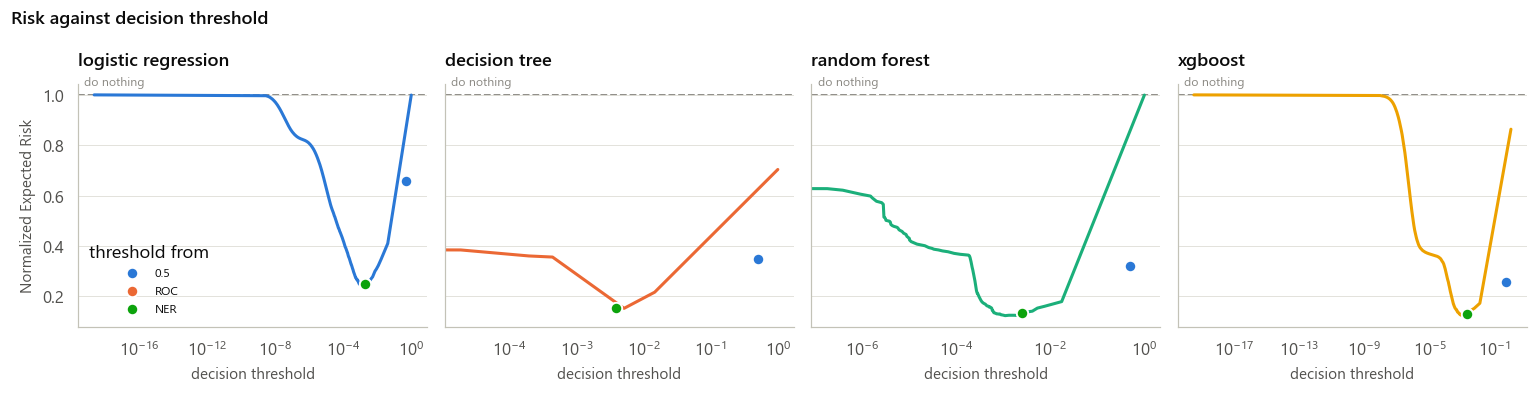

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharey=True)

marker_rows = []
for ax, learner in zip(axes, C.LEARNERS):
    test = cached[(learner, "unweighted", "test")]
    val = cached[(learner, "unweighted", "val")]

    grid, ners = RK.ner_curve(test["y_true"], test["score"], R, n_points=300)
    ax.plot(grid, ners, color=viz.LEARNER_COLORS[learner])

    # Rules are chosen on validation and applied to test -- never chosen here.
    for rule, colour, label in (("fixed", viz.CATEGORICAL[0], "0.5"),
                               ("youden", viz.CATEGORICAL[1], "ROC"),
                               ("ner_optimal", viz.STATUS["good"], "NER")):
        chosen = E.select_threshold(val["y_true"], val["score"], rule, R)
        scored = RK.evaluate_threshold(test["y_true"], test["score"],
                                       chosen.threshold, R, rule=rule)
        ax.scatter([chosen.threshold], [scored.ner], s=55, color=colour,
                   zorder=5, edgecolors="white", linewidths=1.2, label=label)
        marker_rows.append({"learner": learner, "rule": rule,
                            "threshold": chosen.threshold, "ner": scored.ner,
                            "recall": scored.recall, "precision": scored.precision,
                            "n_flagged": scored.n_flagged})

    ax.set(title=learner.replace("_", " "), xscale="log", xlabel="decision threshold")
    viz.despine(ax)

axes[0].set_ylabel("Normalized Expected Risk")
axes[0].legend(title="threshold from", fontsize=8)
for ax in axes:
    viz.annotate_reference(ax, 1.0, "do nothing", axis="y", side="left")

markers = pd.DataFrame(marker_rows)
E.save_results(markers.to_dict("records"), "06_threshold_markers")

fig.suptitle("Risk against decision threshold", x=0.005, ha="left",
             fontsize=12, fontweight="semibold")
fig.tight_layout()
viz.save_figure(fig, "06_ner_vs_threshold")
plt.show()

## ROC-optimal versus risk-optimal

The comparison RQ 2.1.3 asks for. Aleksandrova & Armianova's finding was stark: the statistically optimal cut rejected 42–44% of cases for a *negative* return, while the consequence-optimal cut rejected 13–18% for a strongly positive one.

Alert volume is the column to read alongside NER. A rule that shaves risk while tripling the review queue is not an improvement any fraud team can staff.

In [3]:
wide = markers.pivot_table(index="learner", columns="rule",
                           values=["ner", "recall", "n_flagged", "threshold"])

comparison = pd.DataFrame({
    "ner_default": wide[("ner", "fixed")],
    "ner_roc": wide[("ner", "youden")],
    "ner_risk": wide[("ner", "ner_optimal")],
    "alerts_roc": wide[("n_flagged", "youden")],
    "alerts_risk": wide[("n_flagged", "ner_optimal")],
    "recall_roc": wide[("recall", "youden")],
    "recall_risk": wide[("recall", "ner_optimal")],
})
comparison["alert_ratio_roc_over_risk"] = (comparison["alerts_roc"]
                                           / comparison["alerts_risk"].clip(lower=1))
E.save_results(comparison.reset_index().to_dict("records"), "06_threshold_rule_comparison")
comparison.round(4)

,ner_default,ner_roc,ner_risk,alerts_roc,alerts_risk,recall_roc,recall_risk,alert_ratio_roc_over_risk
learner,,,,,,,,
decision_tree,0.3482,0.1527,0.1527,22812.0,22812.0,0.8701,0.8701,1.0
logistic_regression,0.6591,0.2499,0.2499,58144.0,58144.0,0.8101,0.8101,1.0
random_forest,0.3206,0.1324,0.1324,22033.0,22033.0,0.8896,0.8896,1.0
xgboost,0.2590,0.1314,0.1314,18776.0,18776.0,0.8872,0.8872,1.0


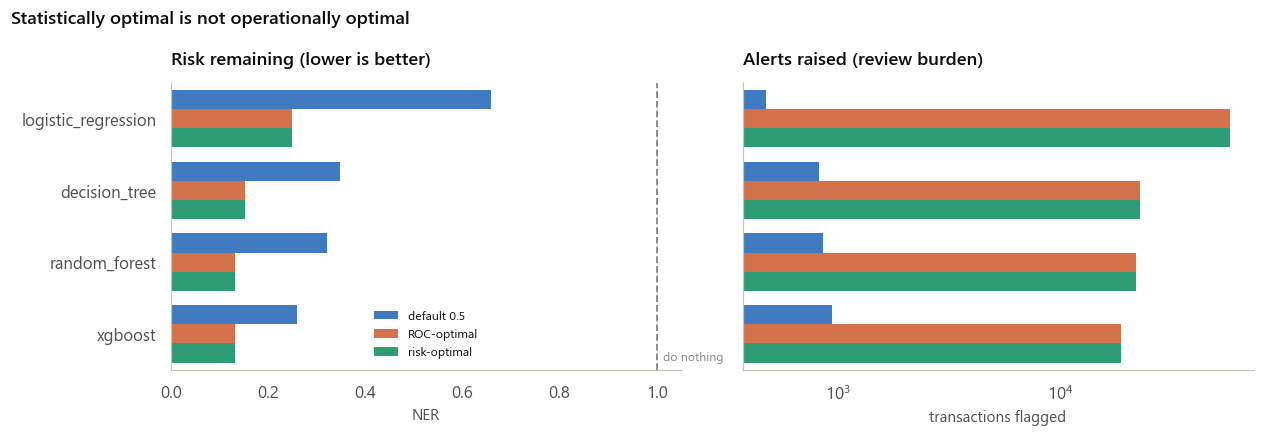

In [4]:
fig, (ax_ner, ax_alerts) = plt.subplots(1, 2, figsize=(11.5, 4))
rule_names = {"fixed": "default 0.5", "youden": "ROC-optimal", "ner_optimal": "risk-optimal"}
plot_df = markers.assign(rule_label=markers["rule"].map(rule_names))
order = list(rule_names.values())

sns.barplot(plot_df, x="ner", y="learner", hue="rule_label", hue_order=order,
            palette=viz.CATEGORICAL[:3], ax=ax_ner)
ax_ner.set(title="Risk remaining (lower is better)", xlabel="NER", ylabel="")
viz.annotate_reference(ax_ner, 1.0, "do nothing", axis="x", below=True)
ax_ner.legend(title="", fontsize=8)

sns.barplot(plot_df, x="n_flagged", y="learner", hue="rule_label", hue_order=order,
            palette=viz.CATEGORICAL[:3], ax=ax_alerts, legend=False)
ax_alerts.set(title="Alerts raised (review burden)", xlabel="transactions flagged",
              ylabel="", xscale="log")
ax_alerts.set_yticklabels([])

for ax in (ax_ner, ax_alerts):
    viz.despine(ax)
    ax.grid(axis="y", visible=False)

fig.suptitle("Statistically optimal is not operationally optimal", x=0.005, ha="left",
             fontsize=12, fontweight="semibold")
fig.tight_layout()
viz.save_figure(fig, "06_threshold_rules")
plt.show()

## Sensitivity to `R`

Proposal §4.5 item 1 asks for sensitivity analysis across cost ratios. `R` is an assumption, not a measurement, so any conclusion that survives only at `R = 774` is not a conclusion worth reporting.

What matters is whether the **ranking** of configurations is stable as `R` moves. If it flips, the recommendation has to be stated conditionally.

In [5]:
sweep_rows = []
for r in C.R_SWEEP:
    for learner in C.LEARNERS:
        for variant in X.FIT_VARIANTS:
            val = cached[(learner, variant, "val")]
            test = cached[(learner, variant, "test")]

            chosen = RK.optimal_threshold(val["y_true"], val["score"], r)
            scored = RK.evaluate_threshold(test["y_true"], test["score"],
                                           chosen.threshold, r)
            sweep_rows.append({"R": r, "learner": learner, "variant": variant,
                               "ner": scored.ner, "recall": scored.recall,
                               "n_flagged": scored.n_flagged,
                               "threshold": chosen.threshold})

sweep = pd.DataFrame(sweep_rows)
E.save_results(sweep.to_dict("records"), "06_r_sweep")

grid = sweep.pivot_table(index="variant", columns="R", values="ner", aggfunc="min")
grid.round(4)

R,1.000000,10.000000,50.000000,100.000000,500.000000,773.701084,1000.000000,2000.000000,5000.000000
variant,,,,,,,,,
instance_weighted,0.3222,0.2573,0.2168,0.1983,0.1589,0.1427,0.1345,0.1009,0.0563
rus,0.4334,0.3230,0.2532,0.2241,0.1468,0.1355,0.1244,0.0871,0.0554
unweighted,0.2792,0.2428,0.1967,0.1864,0.1444,0.1314,0.1161,0.0923,0.0544
weighted,0.3328,0.2596,0.2152,0.1995,0.1515,0.1408,0.1275,0.0978,0.0516


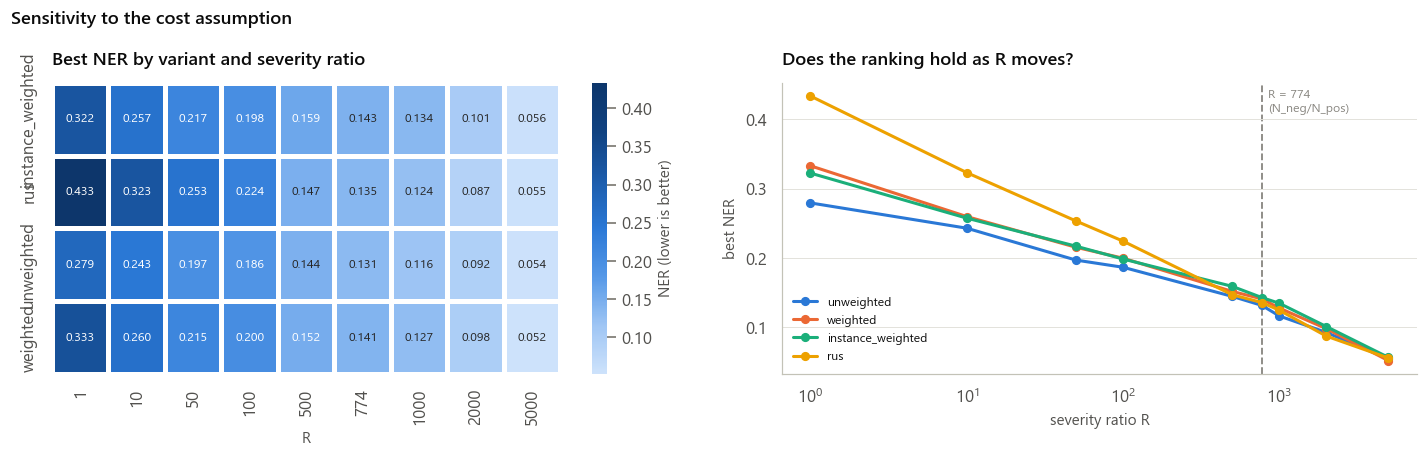

In [6]:
fig, (ax_heat, ax_rank) = plt.subplots(1, 2, figsize=(13, 4.2))

sns.heatmap(grid, cmap=viz.sequential_cmap(), annot=True, fmt=".3f",
            annot_kws={"size": 8}, linewidths=2, linecolor="white",
            cbar_kws={"label": "NER (lower is better)"}, ax=ax_heat)
ax_heat.set(title="Best NER by variant and severity ratio", xlabel="R", ylabel="")
ax_heat.set_xticklabels([f"{float(t.get_text()):.0f}" for t in ax_heat.get_xticklabels()])

for variant, colour in zip(X.FIT_VARIANTS, viz.CATEGORICAL):
    row = sweep[sweep["variant"] == variant].groupby("R")["ner"].min()
    ax_rank.plot(row.index, row.values, marker="o", markersize=5,
                 color=colour, label=variant)

ax_rank.set(title="Does the ranking hold as R moves?", xscale="log",
            xlabel="severity ratio R", ylabel="best NER")
viz.annotate_reference(ax_rank, C.R_DEFAULT, f"R = {C.R_DEFAULT:.0f}\n(N_neg/N_pos)",
                       axis="x")
ax_rank.legend(fontsize=8)
viz.despine(ax_rank)

fig.suptitle("Sensitivity to the cost assumption", x=0.005, ha="left",
             fontsize=12, fontweight="semibold")
fig.tight_layout()
viz.save_figure(fig, "06_r_sensitivity")
plt.show()

## Recall against review capacity

The operational metric, and the one a fraud manager would actually ask for.

Budgets are quoted as **alerts per day**, then scaled to this test set. The test split holds 15% of traffic across the simulation's 31 days, so a team reviewing *k* per day corresponds to `k × 31 × 0.15` alerts here. Stating that scaling explicitly matters: quoting a raw top-*k* on a subsample would silently overstate the capacity.

In [7]:
test_fraction = n_test / C.N_ROWS
n_days = C.MAX_STEP / C.STEPS_PER_DAY

def budget_on_test(per_day: int) -> int:
    """Alerts/day for a full-traffic system -> equivalent count on this split."""
    return max(int(round(per_day * n_days * test_fraction)), 1)

print(f"test set holds {test_fraction:.1%} of traffic over {n_days:.1f} days")
for b in C.REVIEW_BUDGETS:
    print(f"  {b:>5,}/day  ->  {budget_on_test(b):>7,} alerts on this test set")

budget_rows = []
for learner in C.LEARNERS:
    test = cached[(learner, "unweighted", "test")]
    for per_day in C.REVIEW_BUDGETS:
        k = budget_on_test(per_day)
        budget_rows.append({
            "learner": learner, "alerts_per_day": per_day, "k_on_test": k,
            "recall": RK.recall_at_budget(test["y_true"], test["score"], k),
            "precision": RK.precision_at_budget(test["y_true"], test["score"], k),
        })

budgets = pd.DataFrame(budget_rows)
E.save_results(budgets.to_dict("records"), "06_recall_at_budget")
budgets.pivot_table(index="learner", columns="alerts_per_day",
                    values="recall").round(4)

test set holds 15.0% of traffic over 31.0 days
    100/day  ->      464 alerts on this test set
    500/day  ->    2,322 alerts on this test set
  1,000/day  ->    4,644 alerts on this test set
  5,000/day  ->   23,219 alerts on this test set


alerts_per_day,100,500,1000,5000
learner,,,,
decision_tree,0.3766,0.7492,0.7800,0.8701
logistic_regression,0.3393,0.5682,0.6274,0.7492
random_forest,0.3758,0.8109,0.8352,0.8953
xgboost,0.3766,0.8239,0.8450,0.8920


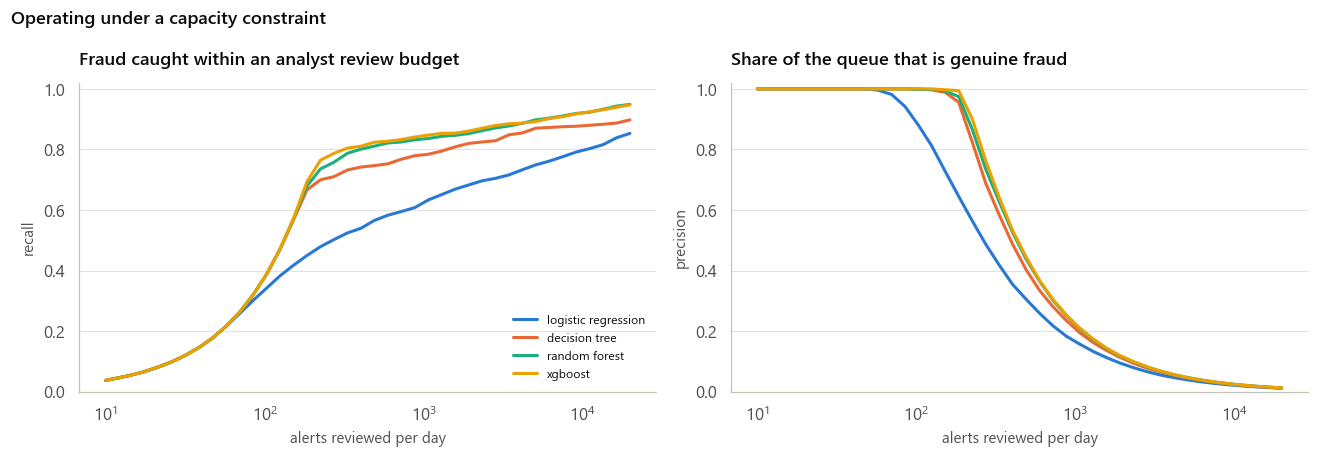

In [8]:
fig, (ax_curve, ax_prec) = plt.subplots(1, 2, figsize=(12, 4.2))
sweep_budgets = np.unique(np.logspace(1, 4.3, 40).astype(int))

for learner in C.LEARNERS:
    test = cached[(learner, "unweighted", "test")]
    recalls, precisions = [], []
    for per_day in sweep_budgets:
        k = budget_on_test(per_day)
        recalls.append(RK.recall_at_budget(test["y_true"], test["score"], k))
        precisions.append(RK.precision_at_budget(test["y_true"], test["score"], k))

    colour = viz.LEARNER_COLORS[learner]
    ax_curve.plot(sweep_budgets, recalls, color=colour, label=learner.replace("_", " "))
    ax_prec.plot(sweep_budgets, precisions, color=colour)

ax_curve.set(title="Fraud caught within an analyst review budget", xscale="log",
             xlabel="alerts reviewed per day", ylabel="recall", ylim=(0, 1.02))
ax_curve.legend(fontsize=8, loc="lower right")

ax_prec.set(title="Share of the queue that is genuine fraud", xscale="log",
            xlabel="alerts reviewed per day", ylabel="precision", ylim=(0, 1.02))

for ax in (ax_curve, ax_prec):
    viz.despine(ax)

fig.suptitle("Operating under a capacity constraint", x=0.005, ha="left",
             fontsize=12, fontweight="semibold")
fig.tight_layout()
viz.save_figure(fig, "06_recall_at_budget")
plt.show()

## Per-transaction thresholds

A single global cut treats a small payment and a large transfer identically. The Bayes rule does not have to: with per-instance severity `s_i` (the amount's percentile rank, unit-free), the threshold becomes

$$\lambda_i = \frac{1}{1 + R \cdot s_i}$$

so larger transfers face a lower bar. If this beats the best global threshold it is a second contribution  and it is exactly the case-based costing Aleksandrova & Armianova named as future work.

In [9]:
rows = []
for learner in C.LEARNERS:
    test = cached[(learner, "unweighted", "test")]
    val = cached[(learner, "unweighted", "val")]
    sev_test, sev_val = test["severity"].to_numpy(), val["severity"].to_numpy()

    # Global: one threshold chosen on validation under severity weighting.
    chosen = RK.optimal_threshold(val["y_true"], val["score"], R, sev_val)
    glob = RK.evaluate_threshold(test["y_true"], test["score"], chosen.threshold,
                                 R, sev_test, rule="global")

    # Per-transaction: the closed-form Bayes rule, no fitting at all.
    per_txn_thresholds = RK.per_transaction_thresholds(sev_test, R)
    per = RK.evaluate_threshold(test["y_true"], test["score"], per_txn_thresholds,
                                R, sev_test, rule="per_transaction")

    for label, result in (("global", glob), ("per-transaction", per)):
        rows.append({"learner": learner, "rule": label, "ner": result.ner,
                     "recall": result.recall, "precision": result.precision,
                     "n_flagged": result.n_flagged})

per_txn = pd.DataFrame(rows)
E.save_results(per_txn.to_dict("records"), "06_per_transaction_threshold")
per_txn.round(4)

,learner,rule,ner,recall,precision,n_flagged
0,logistic_regression,global,0.2314,0.7946,0.0222,44067
1,logistic_regression,per-transaction,0.2216,0.8214,0.0152,66440
2,decision_tree,global,0.1407,0.8701,0.0470,22812
3,decision_tree,per-transaction,0.1410,0.8571,0.0481,21949
4,random_forest,global,0.1198,0.8880,0.0520,21053
5,random_forest,per-transaction,0.1169,0.8920,0.0374,29372
6,xgboost,global,0.1148,0.8791,0.0822,13182
7,xgboost,per-transaction,0.1134,0.8807,0.0593,18285


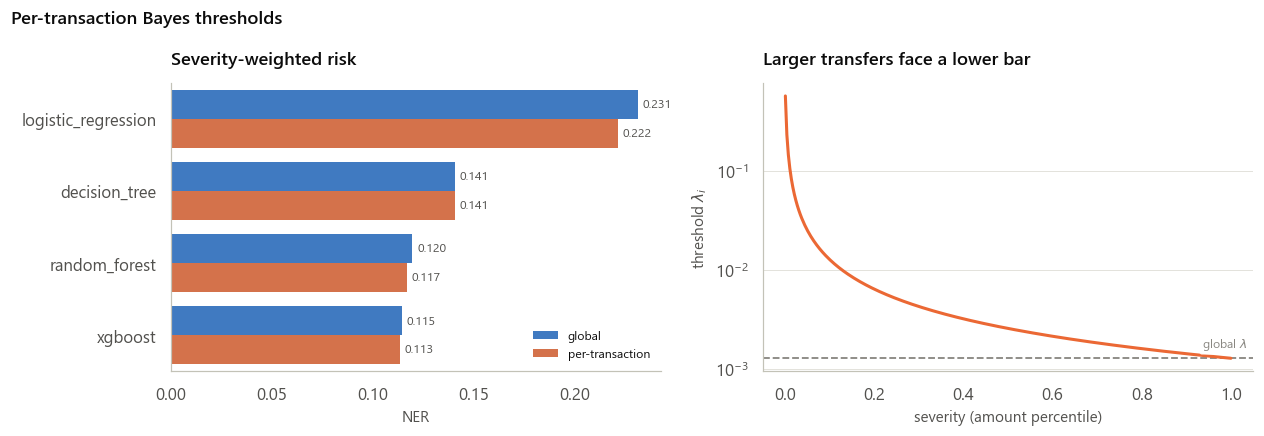

In [10]:
fig, (ax_ner, ax_curve) = plt.subplots(1, 2, figsize=(11.5, 4))

sns.barplot(per_txn, x="ner", y="learner", hue="rule",
            palette=viz.CATEGORICAL[:2], ax=ax_ner)
viz.value_labels(ax_ner, fmt=lambda v: f"{v:.3f}")
ax_ner.set(title="Severity-weighted risk", xlabel="NER", ylabel="")
ax_ner.legend(title="", fontsize=8)
viz.despine(ax_ner)
ax_ner.grid(axis="y", visible=False)

severity_grid = np.linspace(0.001, 1.0, 300)
ax_curve.plot(severity_grid, RK.per_transaction_thresholds(severity_grid, R),
              color=viz.CATEGORICAL[1])
ax_curve.set(title="Larger transfers face a lower bar", yscale="log",
             xlabel="severity (amount percentile)", ylabel=r"threshold $\lambda_i$")
viz.annotate_reference(ax_curve, RK.bayes_threshold(R), "global $\\lambda$",
                       axis="y", side="right")
viz.despine(ax_curve)

fig.suptitle("Per-transaction Bayes thresholds", x=0.005, ha="left",
             fontsize=12, fontweight="semibold")
fig.tight_layout()
viz.save_figure(fig, "06_per_transaction")
plt.show()

## Risk bands

The operational output, mapped to the Fraud Management System in the proposal's Figure 1. Cutoffs are anchored on the Bayes threshold rather than round numbers: **High** begins at `λ`  the point where flagging starts reducing risk  with **Medium** an order of magnitude below and **Critical** an order above.

The *step-up authentication* band is the one that connects this back to the USSD and 2FA literature: it is the response for transactions that are suspicious but not damning.

In [11]:
cutoffs = RK.band_cutoffs(R)
print("Band cutoffs on the 0-100 risk scale:")
for band, value in cutoffs.items():
    print(f"  {band:9s} >= {value:8.4f}   -> {C.BAND_ACTIONS[band]}")
print(f"  {'Low':9s}  <  {cutoffs['Medium']:8.4f}   -> {C.BAND_ACTIONS['Low']}")

band_rows = []
for learner in C.LEARNERS:
    test = cached[(learner, "unweighted", "test")]
    scores = RK.risk_score(test["score"])
    bands = RK.assign_bands(scores, cutoffs)

    for band in ("Low", "Medium", "High", "Critical"):
        mask = bands == band
        n = int(mask.sum())
        band_rows.append({
            "learner": learner, "band": band, "action": C.BAND_ACTIONS[band],
            "n_transactions": n,
            "share": n / len(scores),
            "n_fraud": int(test["y_true"].to_numpy()[mask].sum()),
            "fraud_rate": float(test["y_true"].to_numpy()[mask].mean()) if n else 0.0,
        })

bands_df = pd.DataFrame(band_rows)
E.save_results(bands_df.to_dict("records"), "06_risk_bands")
bands_df.pivot_table(index="learner", columns="band",
                     values="fraud_rate").round(5)

Band cutoffs on the 0-100 risk scale:
  Medium    >=   0.0129   -> monitor
  High      >=   0.1291   -> step_up_auth
  Critical  >=   1.2908   -> block
  Low        <    0.0129   -> allow


band,Critical,High,Low,Medium
learner,,,,
decision_tree,0.17619,0.00584,0.00000,0.00049
logistic_regression,0.09829,0.00261,0.00006,0.00057
random_forest,0.26380,0.00296,0.00000,0.00034
xgboost,0.32914,0.00361,0.00002,0.00049


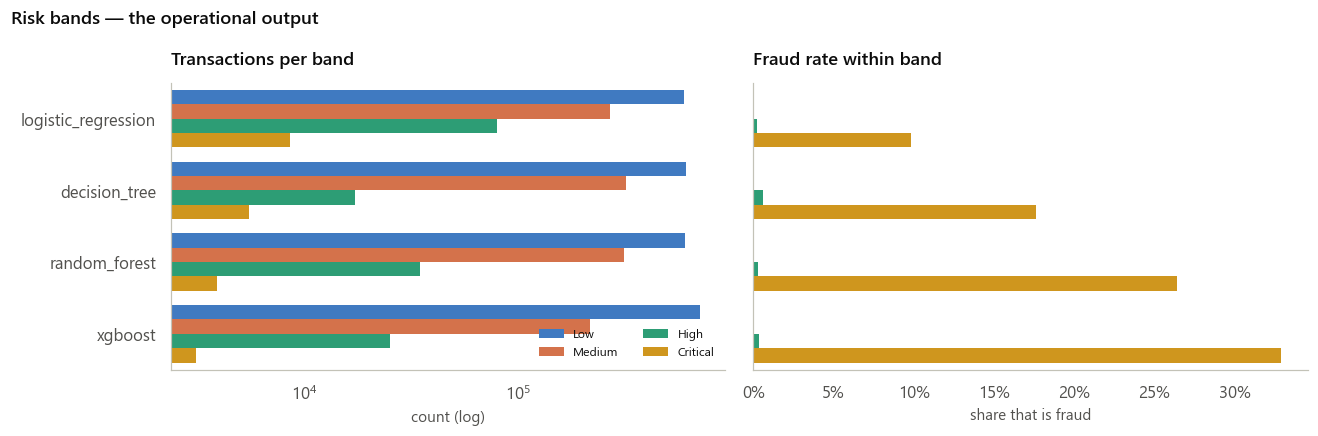

In [12]:
fig, (ax_vol, ax_rate) = plt.subplots(1, 2, figsize=(12, 4))
band_order = ["Low", "Medium", "High", "Critical"]

sns.barplot(bands_df, x="n_transactions", y="learner", hue="band",
            hue_order=band_order, palette=viz.CATEGORICAL, ax=ax_vol)
ax_vol.set(title="Transactions per band", xlabel="count (log)", ylabel="", xscale="log")
ax_vol.legend(title="", fontsize=8, ncol=2)

sns.barplot(bands_df, x="fraud_rate", y="learner", hue="band",
            hue_order=band_order, palette=viz.CATEGORICAL, ax=ax_rate, legend=False)
ax_rate.set(title="Fraud rate within band", xlabel="share that is fraud", ylabel="")
ax_rate.xaxis.set_major_formatter(viz.percent_formatter(0))
ax_rate.set_yticklabels([])

for ax in (ax_vol, ax_rate):
    viz.despine(ax)
    ax.grid(axis="y", visible=False)

fig.suptitle("Risk bands: the operational output", x=0.005, ha="left",
             fontsize=12, fontweight="semibold")
fig.tight_layout()
viz.save_figure(fig, "06_risk_bands")
plt.show()

In [13]:
summary = {
    "rung": RUNG,
    "R": float(R),
    "lambda": float(RK.bayes_threshold(R)),
    "band_cutoffs": {k: float(v) for k, v in cutoffs.items()},
    "best_ner": float(markers["ner"].min()),
    "best_ner_learner": markers.loc[markers["ner"].idxmin(), "learner"],
    "best_ner_rule": markers.loc[markers["ner"].idxmin(), "rule"],
    "per_transaction_wins": bool(
        per_txn.query("rule == 'per-transaction'")["ner"].min()
        < per_txn.query("rule == 'global'")["ner"].min()
    ),
}
E.save_json(summary, "06_risk_summary")

for key, value in summary.items():
    print(f"  {key:24s} {value}")
print("\nNext: 07_interpretability.ipynb, then 08_model_export.ipynb.")

  rung                     no_origin_balance
  R                        773.7010836478753
  lambda                   0.0012908204481801523
  band_cutoffs             {'Medium': 0.012908204481801522, 'High': 0.12908204481801522, 'Critical': 1.2908204481801522}
  best_ner                 0.13137587645252166
  best_ner_learner         xgboost
  best_ner_rule            youden
  per_transaction_wins     True

Next: 07_interpretability.ipynb, then 08_model_export.ipynb.
